# Conservative vs Non-Conservative Fields in Electrodynamics

The electrostatic field is **conservative**: curl-free, path-independent, $\oint\mathbf E\cdot d\boldsymbol\ell=0$,
and derivable from a single-valued potential $\mathbf E=-\nabla V$. That is the world of the
electrostatics chapters.

Electrodynamics breaks it. Faraday's law

$$\nabla\times\mathbf E=-\frac{\partial\mathbf B}{\partial t}$$

means a *changing magnetic field* makes $\mathbf E$ **non-conservative**: it circulates,
$\oint\mathbf E\cdot d\boldsymbol\ell=-\dfrac{d\Phi_B}{dt}\neq0$ (an EMF), and there is no
single-valued potential. The four equivalent faces of "conservative" all fail at once. This is the
hinge between statics and dynamics — and the principle of every generator, transformer, and the motor
back-EMF. Engine: `griffiths` (curl, conservative test).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Math
import griffiths as gr
from griffiths import x, y, z

sp.init_printing(use_latex="mathjax")
print("griffiths loaded")

griffiths loaded


## 1 — Conservative: the four equivalent conditions

For a static field these are all the same statement: (i) $\nabla\times\mathbf F=0$; (ii)
$\oint\mathbf F\cdot d\boldsymbol\ell=0$; (iii) the work is path-independent; (iv) $\mathbf F=-\nabla V$.
Take the curl-free field $\mathbf F=(y,x,0)$: it passes the test, has a potential, and does zero net
work around a loop.

In [ ]:
F = sp.Matrix([y, x, 0])
ok, curlF = gr.is_conservative(F), gr.curl(F)
display(Math(r"\mathbf F = " + sp.latex(F.T) + r",\quad \nabla\times\mathbf F = "
             + sp.latex(curlF.T) + (r"\;=0\ \Rightarrow\ \textbf{conservative}" if curlF == sp.zeros(3,1) else "")))
V = gr.scalar_potential(F)
display(Math(r"\mathbf F = -\nabla V,\quad V = " + sp.latex(V)))

# closed-loop work: integrate F.dl around the unit circle -> 0
t = sp.Symbol("t"); xc, yc = sp.cos(t), sp.sin(t)
dl = sp.Matrix([sp.diff(xc, t), sp.diff(yc, t), 0])
work = sp.integrate(F.subs({x: xc, y: yc}).dot(dl), (t, 0, 2*sp.pi))
display(Math(r"\oint_{\rm circle}\mathbf F\cdot d\boldsymbol\ell = " + sp.latex(work)
             + r"\quad(\text{path-independent, no net work})"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

: 

## 2 — Non-conservative: the Faraday-induced field

A long solenoid with a *changing* field $B(t)\hat z$ inside radius $R$. By symmetry the induced
$\mathbf E$ circles the axis, and Faraday gives (for a loop of radius $s<R$)
$2\pi s\,E_\phi=-\pi s^2\,\dot B$, i.e. $E_\phi=-\tfrac{s}{2}\dot B$. In Cartesian that is a swirl
$\mathbf E=-\tfrac12\dot B\,(-y,\,x,\,0)$ — and its curl is exactly $-\dot B\,\hat z$.

In [3]:
Bdot = sp.Symbol("Bdot", real=True)     # dB/dt
E_ind = -sp.Rational(1, 2) * Bdot * sp.Matrix([-y, x, 0])
display(Math(r"\mathbf E_{\rm induced} = " + sp.latex(E_ind.T)))
display(Math(r"\nabla\times\mathbf E_{\rm induced} = " + sp.latex(gr.curl(E_ind).T)
             + r" = -\dot B\,\hat z = -\frac{\partial\mathbf B}{\partial t}\ \checkmark\ \text{(Faraday)}"))
print("conservative?", gr.is_conservative(E_ind), " -> NO (curl != 0)")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

conservative? False  -> NO (curl != 0)


In [4]:
# the EMF: closed-loop integral is NOT zero -> it equals -dPhi/dt
s = sp.Symbol("s", positive=True)
xc, yc = s*sp.cos(t), s*sp.sin(t)
dl = sp.Matrix([sp.diff(xc, t), sp.diff(yc, t), 0])
emf = sp.integrate(E_ind.subs({x: xc, y: yc}).dot(dl), (t, 0, 2*sp.pi))
display(Math(r"\oint\mathbf E_{\rm induced}\cdot d\boldsymbol\ell = " + sp.latex(sp.simplify(emf))
             + r" = -\dot B\,(\pi s^2) = -\frac{d\Phi_B}{dt}\ \ne 0"))
print("a charge dragged around the loop GAINS energy each lap -> drives a current (the EMF).")

<IPython.core.display.Math object>

a charge dragged around the loop GAINS energy each lap -> drives a current (the EMF).


## 3 — Side by side: a gradient field vs a swirl

The conservative field points 'downhill' (it has a potential, equipotentials exist); the induced
field **circulates** (closed loops, no potential). Drag a charge once around: zero net work on the
left, a full EMF on the right.

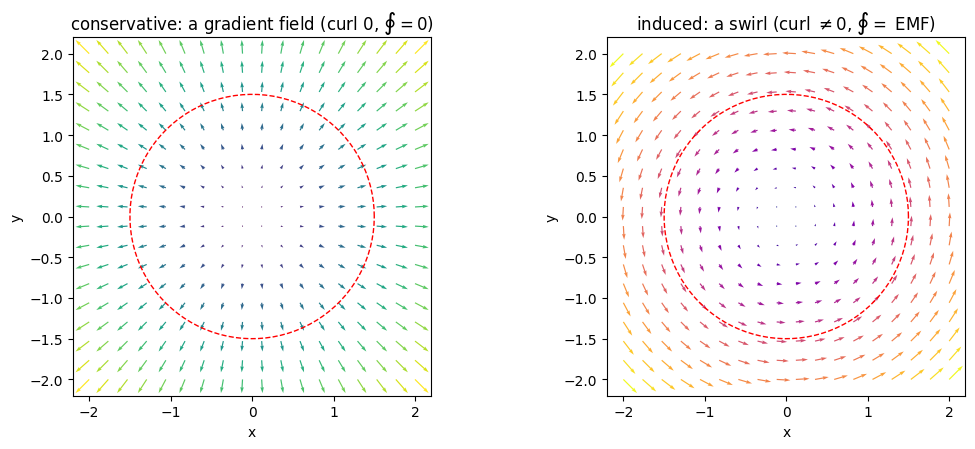

In [5]:
gx, gy = np.meshgrid(np.linspace(-2, 2, 18), np.linspace(-2, 2, 18))
fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
# conservative F = grad of (x^2+y^2)/... use radial gradient field (curl-free): (x, y)
ax[0].quiver(gx, gy, gx, gy, np.hypot(gx, gy), cmap="viridis")
th = np.linspace(0, 2*np.pi, 100); ax[0].plot(1.5*np.cos(th), 1.5*np.sin(th), "r--", lw=1)
ax[0].set_aspect("equal"); ax[0].set_title("conservative: a gradient field (curl 0, $\\oint=0$)")
# induced (swirl): (-y, x)
ax[1].quiver(gx, gy, -gy, gx, np.hypot(gx, gy), cmap="plasma")
ax[1].plot(1.5*np.cos(th), 1.5*np.sin(th), "r--", lw=1)
ax[1].set_aspect("equal"); ax[1].set_title("induced: a swirl (curl $\\ne$0, $\\oint=$ EMF)")
for a in ax:
    a.set_xlabel("x"); a.set_ylabel("y")
plt.tight_layout(); plt.show()

## 4 — Why the distinction runs the machines

- **Conservative = energy stored and returned.** The electrostatic field does no net work around a
  loop; its energy lives in the potential $V$ (capacitors store, then give back). Earnshaw, the
  mean-value property, and the existence of $V$ all rest on $\nabla\times\mathbf E=0$.
- **Non-conservative = energy delivered.** The induced field's $\oint\mathbf E\cdot d\boldsymbol\ell\neq0$
  is an EMF that pushes charge around a circuit lap after lap — this is the **generator** (move a
  magnet, get current), the **transformer** (changing flux couples two coils), and the **back-EMF**
  that limits the DC motor in `dc_motor_model.ipynb`.
- **The curl is the switch.** $\nabla\times\mathbf E=0$ vs $-\partial_t\mathbf B$ is the single line
  separating electrostatics from electrodynamics. Add Maxwell's displacement-current correction to
  $\nabla\times\mathbf B$ and the same non-conservative coupling closes the loop into propagating
  electromagnetic waves — the light the rest of this repo measures.

Built on `griffiths` (`curl`, `is_conservative`, `scalar_potential`); the induced field verifies
Faraday's law $\nabla\times\mathbf E=-\partial_t\mathbf B$ exactly.